Chiller Efficiency in kW/ton?  .08
Cost of kW/Hr?  .11


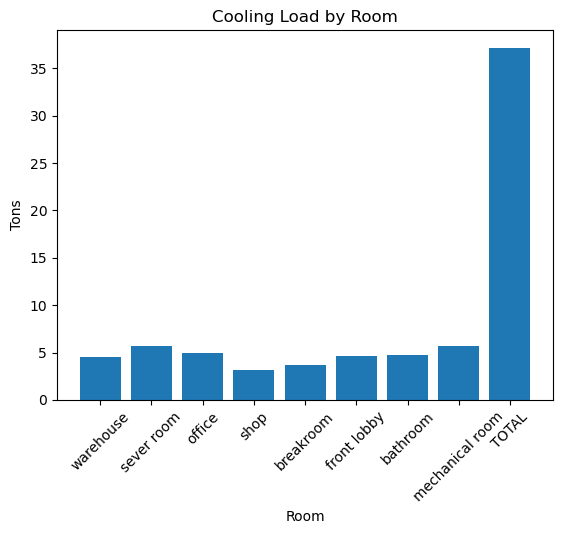

Results saved to output.csv


In [55]:
#Import CSV file
import pandas as pd

#User Input for kW/ton and kW/Hr Cost
kw_ton = float(input("Chiller Efficiency in kW/ton? "))
kwhr_cost = float(input("Cost of kW/Hr? "))

#Define Cooling Load Function
def cooling_load(CFM, supply_temp, return_temp):
    delta_t = return_temp - supply_temp
    BtuH = CFM * delta_t * 1.085
    tons = BtuH / 12000
    return BtuH, tons
#a typical chiller runs around 0.6-1.2 kW/ton) and a $/kWh rate (around $0.12 is realistic).
def summarize_loads(rooms):
    results = []
    
    for room in rooms:
        btu, tons = cooling_load(room["cfm"],room["t_supply"],room["t_return"])
        if room["cfm"] < 1000:
            print("WARNING", room["name"], "is running under 1000 CFM")
            
        #print(room["name"], "->",(round(btu,2)) , "BTU/hr,",(round(tons,2)), "tons")
        results.append({
            "name" : room["name"],
            "btu" : btu,
            "tons" : tons,
        })

    total_BtuH = sum(r["btu"] for r in results)
    total_tons = total_BtuH/12000

    #Cost Calculator
    total_kW = kw_ton * total_tons
    monthly_cost = total_kW * kwhr_cost * 30 * 24

    #Calculate percent of total code
    for r in results:
        percent = (r["btu"]/total_BtuH) * 100
        r["percent"] = percent
        #print(r["name"],":", round(percent,2),"% of total load")
        if r["tons"] > 12:
            print("WARNING",r["name"],"EXCEEDS 12 TONS!!")
   
    #Print all values
    #print("Total BTU/hr:", round(total_BtuH, 2))
    #print("Total Tons:", round(total_tons, 2))
    #print("Total kW:", round(total_kW, 3))
    #print("Monthly Cost:","$",round(monthly_cost, 2))
    results.append({
        "name": "TOTAL",
        "btu": round(total_BtuH, 2),
        "tons": round(total_tons, 2),
        "percent": 100.0
    })
        # turn results into a dataframe
    df_results = pd.DataFrame(results)
    
    # export to csv
    df_results.to_csv("output.csv", index=False)
    
    print("Results saved to output.csv")
    
    return results, total_BtuH,total_tons
import matplotlib.pyplot as plt
names = [r["name"] for r in results]
tons_list = [r["tons"] for r in results]

plt.bar(names, tons_list)
plt.title("Cooling Load by Room")
plt.xlabel("Room")
plt.ylabel("Tons")
plt.xticks(rotation=45)

plt.show()

if __name__ == "__main__":
    df = pd.read_csv("HVACroomsCSVpractice.csv")
    rooms = df.to_dict(orient="records")
    results, total_BtuH, total_tons = summarize_loads(rooms)